In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PATH = "/content/drive/MyDrive/Cursos/MachineLearning/ML2025III/Laboratorio/Dataset/BandGap"

In [4]:
def load_split(path, split_name):
    split_dir = os.path.join(path, split_name)
    files = sorted(glob.glob(os.path.join(split_dir, f"{split_name}*.csv")))
    dfs = []
    for f in files:
        fold_id = int(os.path.basename(f).replace(split_name, "").replace(".csv",""))
        df = pd.read_csv(f)
        df.columns = [c.strip() for c in df.columns]
        df["__split"] = split_name
        df["__fold"]  = fold_id
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

train_all = load_split(PATH, "train")
val_all   = load_split(PATH, "val")
test_all  = load_split(PATH, "test")

print(train_all.shape, val_all.shape, test_all.shape)
train_all.head()

(2430, 9) (130, 9) (140, 9)


,Compound,Space group,Eg (exp.; eV),Typea,Eg (PBE; eV),Eg (mBJ; eV),Eg(G0W0; eV),__split,__fold
0,Al2CdTe4,82,NaN,D,1.61,2.36,2.86,train,0
1,Al2O3,167,NaN,D,5.88,7.59,9.30,train,0
2,Al2ZnS4,227,NaN,D,2.50,3.58,3.99,train,0
3,Al2ZnSe4,82,NaN,D,2.13,3.24,3.77,train,0
4,AlAs,186,NaN,I,1.74,2.38,2.59,train,0


In [5]:
TARGET   = "Eg(G0W0; eV)"
COL_SG   = "Space group"
COL_TYPE = "Typea"
COL_PBE  = "Eg (PBE; eV)"
COL_MBJ  = "Eg (mBJ; eV)"
COL_EXP  = "Eg (exp.; eV)"
COL_COMP = "Compound"

def to_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

num_cols = [COL_SG, COL_PBE, COL_MBJ, COL_EXP, TARGET]
train_all = to_numeric(train_all, num_cols)
val_all   = to_numeric(val_all, num_cols)
test_all  = to_numeric(test_all, num_cols)

# Eliminamos las filas sin target
train_all = train_all.dropna(subset=[TARGET]).reset_index(drop=True)
val_all   =   val_all.dropna(subset=[TARGET]).reset_index(drop=True)
test_all  =  test_all.dropna(subset=[TARGET]).reset_index(drop=True)

Missing train:
 Eg (exp.; eV)    0.888889
dtype: float64


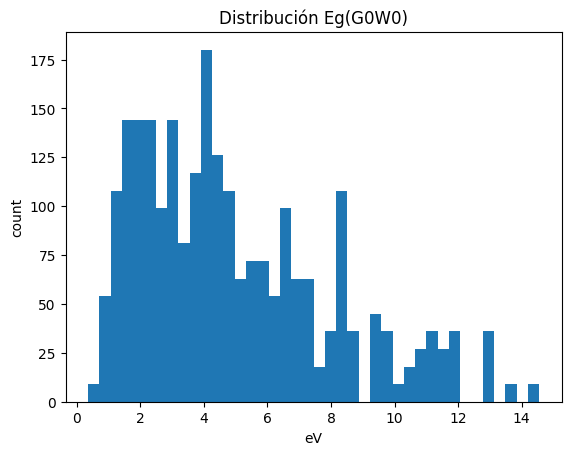

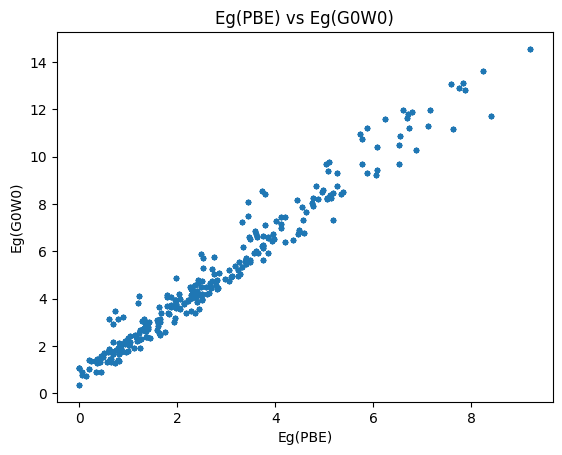

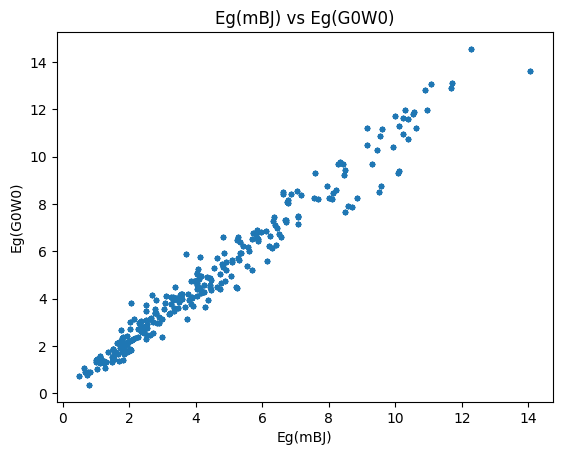

In [6]:
def missing_ratio(df):
    m = df.isna().mean().sort_values(ascending=False)
    return m[m>0]

print("Missing train:\n", missing_ratio(train_all).head(15))

plt.figure()
plt.hist(train_all[TARGET].values, bins=40)
plt.title("Distribución Eg(G0W0)")
plt.xlabel("eV"); plt.ylabel("count")
plt.show()

plt.figure()
plt.scatter(train_all[COL_PBE], train_all[TARGET], s=8)
plt.title("Eg(PBE) vs Eg(G0W0)")
plt.xlabel("Eg(PBE)"); plt.ylabel("Eg(G0W0)")
plt.show()

plt.figure()
plt.scatter(train_all[COL_MBJ], train_all[TARGET], s=8)
plt.title("Eg(mBJ) vs Eg(G0W0)")
plt.xlabel("Eg(mBJ)"); plt.ylabel("Eg(G0W0)")
plt.show()

# Preprocesamiento

In [7]:
FEATURES_NUM = [COL_SG, COL_PBE, COL_MBJ]
FEATURES_CAT = [COL_TYPE]

In [8]:
"""Calcula:
    - mediana (imputación)
    - media/std (scaling)
    - categorías (one-hot)
"""
def fit_preprocess_stats(df):

    df = df.copy()

    # medianas para rellenar NaNs
    med = {c: np.nanmedian(df[c].values) for c in FEATURES_NUM}

    # imputar en copia temporal para stats de scaling
    Xn = np.column_stack([np.where(np.isnan(df[c].values), med[c], df[c].values) for c in FEATURES_NUM])
    mu = Xn.mean(axis=0)
    sig = Xn.std(axis=0) + 1e-12

    # categorías para one-hot (Typea)
    cat_vals = df[COL_TYPE].astype(str).str.strip().fillna("missing").values
    cats = sorted(list(pd.unique(cat_vals)))
    return med, mu, sig, cats

def transform(df, med, mu, sig, cats, add_bias=True):
    """Aplica imputación+scaling+one-hot según stats del train."""
    df = df.copy()

    # numéricas
    Xn = np.column_stack([np.where(np.isnan(df[c].values), med[c], df[c].values) for c in FEATURES_NUM])
    Xn = (Xn - mu) / sig

    # one-hot Typea
    cat_vals = df[COL_TYPE].astype(str).str.strip().fillna("missing").values
    Xc = np.zeros((len(df), len(cats)), dtype=float)
    cat_to_idx = {c:i for i,c in enumerate(cats)}
    for i,v in enumerate(cat_vals):
        if v in cat_to_idx:
            Xc[i, cat_to_idx[v]] = 1.0

    X = np.hstack([Xn, Xc])
    if add_bias:
        X = np.hstack([np.ones((X.shape[0],1)), X])
    y = df[TARGET].values.astype(float)
    return X, y

In [9]:
def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat)**2)))

def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2) + 1e-12
    return float(1 - ss_res/ss_tot)

# Modelos

#### OLS

In [10]:
def fit_ols(X, y):
    # w = (X^T X)^(-1) X^T
    # usamos pseudo-inversa por estabilidad
    w = np.linalg.pinv(X) @ y
    return w

def predict(X, w):
    return X @ w

#### Ridge

Ridge regression resuelve:
$$
\min_w \ \frac{1}{n}||y - Xw||_2^2 + \lambda ||w||_2^2
$$

La solución cerrada es:
$$
w = (X^T X + \lambda I)^{-1} X^T y
$$


In [11]:
def fit_ridge(X, y, lam):
    # w = (X^T X + lam*I)^(-1) X^T y
    d = X.shape[1]
    I = np.eye(d)
    I[0,0] = 0.0  # no regularizar bias
    w = np.linalg.solve(X.T @ X + lam*I, X.T @ y)
    return w

#### Gradient Descent

In [12]:
def fit_gd(X, y, lr=0.05, iters=3000):
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for t in range(iters):
        yhat = X @ w
        err = yhat - y
        loss = (err @ err) / n
        grad = (2.0/n) * (X.T @ err)
        w -= lr * grad
        if t % 50 == 0:
            losses.append(loss)
    return w, losses

#### Lasso

In [13]:
def soft_threshold(a, lam):
    if a > lam:  return a - lam
    if a < -lam: return a + lam
    return 0.0

def fit_lasso_cd(X, y, lam, iters=200):
    # Min (1/2n)||y - Xw||^2 + lam||w||_1
    # Asumimos X ya estandarizado y con bias en X[:,0]
    # No regularizamos bias
    n, d = X.shape
    w = np.zeros(d)

    X_sq = (X**2).sum(axis=0) + 1e-12
    for _ in range(iters):
        yhat = X @ w
        for j in range(d):
            r = y - (yhat - X[:,j]*w[j])
            rho = (X[:,j] @ r)

            if j == 0:
                w_new = rho / X_sq[j]
            else:
                w_new = soft_threshold(rho / X_sq[j], lam / X_sq[j])

            yhat += X[:,j]*(w_new - w[j])
            w[j] = w_new
    return w

#### Polynomial regression

In [14]:
def poly_expand_num(X_no_bias, num_dim, degree):
    # Expandimos polinomios solo sobre las primeras num_dim columnas.
    Znum = X_no_bias[:, :num_dim]
    rest = X_no_bias[:, num_dim:]  # No usamos polinomios en los onehot

    feats = [Znum]  # grado 1
    if degree >= 2:
        for deg in range(2, degree+1):
            cols = []
            for comb in combinations_with_replacement(range(num_dim), deg):
                term = np.prod(Znum[:, comb], axis=1, keepdims=True)
                cols.append(term)
            feats.append(np.hstack(cols))
    Zpoly = np.hstack(feats)
    Xexp = np.hstack([Zpoly, rest])  # Retornamos los onehot
    return Xexp

def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

## Evaluación

In [15]:
def get_fold(df, k):
    return df[df["__fold"] == k].reset_index(drop=True)

def eval_model_over_folds(fit_fn, pred_fn, model_name, extra=None):
    rows = []
    for k in range(10):
        tr = get_fold(train_all, k)
        va = get_fold(val_all, k)

        med, mu, sig, cats = fit_preprocess_stats(tr)
        Xtr, ytr = transform(tr, med, mu, sig, cats, add_bias=False)
        Xva, yva = transform(va, med, mu, sig, cats, add_bias=False)

        # Xtr/Xva sin bias para generar polinomios
        if extra and extra.get("poly_degree", 1) > 1:
            deg = extra["poly_degree"]
            Xtr = poly_expand_num(Xtr, num_dim=len(FEATURES_NUM), degree=deg)
            Xva = poly_expand_num(Xva, num_dim=len(FEATURES_NUM), degree=deg)

        Xtr_b = add_bias(Xtr)
        Xva_b = add_bias(Xva)

        w = fit_fn(Xtr_b, ytr)
        yhat = pred_fn(Xva_b, w)

        rows.append({
            "model": model_name, "fold": k,
            "RMSE": rmse(yva, yhat),
            "MAE": mae(yva, yhat),
            "R2":  r2(yva, yhat)
        })
    dfm = pd.DataFrame(rows)
    return dfm, dfm[["RMSE","MAE","R2"]].mean()

# Ejecutar

#### OLS

In [16]:
ols_df, ols_mean = eval_model_over_folds(
    fit_fn=lambda X,y: fit_ols(X,y),
    pred_fn=predict,
    model_name="OLS"
)
ols_mean

,0
RMSE,0.467792
MAE,0.348394
R2,0.957136


#### Gradient Descent

In [17]:
def fit_gd_wrapper(X, y):
    w, losses = fit_gd(X, y, lr=0.05, iters=3000)
    return w

gd_df, gd_mean = eval_model_over_folds(
    fit_fn=fit_gd_wrapper,
    pred_fn=predict,
    model_name="GD_linear"
)
gd_mean

,0
RMSE,0.467792
MAE,0.348394
R2,0.957136


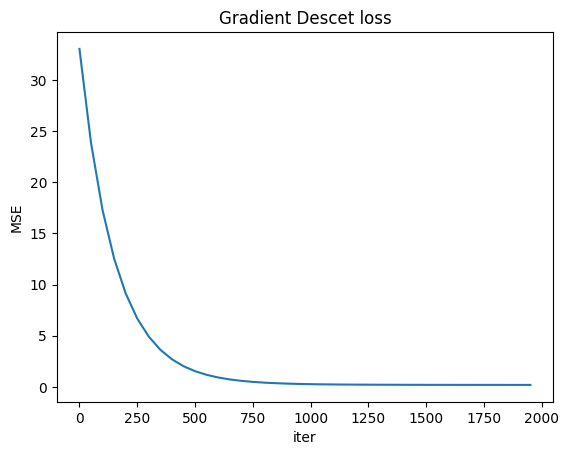

In [18]:
k=0
tr = get_fold(train_all, k)
med, mu, sig, cats = fit_preprocess_stats(tr)
Xtr, ytr = transform(tr, med, mu, sig, cats, add_bias=False)
Xtr = add_bias(Xtr)
w, losses = fit_gd(Xtr, ytr, lr=0.001, iters=2000)

plt.figure()
plt.plot(np.arange(len(losses))*50, losses)
plt.title("Gradient Descet loss")
plt.xlabel("iter"); plt.ylabel("MSE")
plt.show()

#### Ridge

In [19]:
lams = [1e-4,1e-3,1e-2,1e-1,1,10,100]

ridge_grid = []
for lam in lams:
    dfm, meanm = eval_model_over_folds(
        fit_fn=lambda X,y,lam=lam: fit_ridge(X,y,lam),
        pred_fn=predict,
        model_name=f"Ridge(lam={lam})"
    )
    ridge_grid.append({"lam":lam, **meanm.to_dict()})
pd.DataFrame(ridge_grid).sort_values("RMSE").head(10)

,lam,RMSE,MAE,R2
4,1.0000,0.467654,0.348214,0.957170
3,0.1000,0.467773,0.348374,0.957140
2,0.0100,0.467790,0.348392,0.957137
1,0.0010,0.467792,0.348394,0.957136
0,0.0001,0.467792,0.348394,0.957136
5,10.0000,0.470151,0.348812,0.956950
6,100.0000,0.653497,0.519690,0.926785


#### Lasso

In [20]:
lams_l1 = [1e-4,1e-3,1e-2,1e-1,1e0]

lasso_grid = []
for lam in lams_l1:
    dfm, meanm = eval_model_over_folds(
        fit_fn=lambda X,y,lam=lam: fit_lasso_cd(X,y,lam, iters=200),
        pred_fn=predict,
        model_name=f"Lasso(lam={lam})"
    )
    lasso_grid.append({"lam":lam, **meanm.to_dict()})
pd.DataFrame(lasso_grid).sort_values("RMSE").head(10)

,lam,RMSE,MAE,R2
0,0.0001,0.467792,0.348394,0.957136
1,0.0010,0.467792,0.348394,0.957136
2,0.0100,0.467794,0.348394,0.957135
3,0.1000,0.467818,0.348401,0.957122
4,1.0000,0.468143,0.348466,0.956979


#### Polynomial con Ridge

In [21]:
poly_grid = []
for deg in [1,2,3,4]:
    for lam in [1e-3,1e-2,1e-1,1,10,100]:
        dfm, meanm = eval_model_over_folds(
            fit_fn=lambda X,y,lam=lam: fit_ridge(X,y,lam),
            pred_fn=predict,
            model_name=f"Poly{deg}+Ridge({lam})",
            extra={"poly_degree":deg}
        )
        poly_grid.append({"degree":deg,"lam":lam, **meanm.to_dict()})

poly_df = pd.DataFrame(poly_grid).sort_values("RMSE")
poly_df.head(12)

,degree,lam,RMSE,MAE,R2
20,4,0.100,0.408873,0.303372,0.968181
19,4,0.010,0.409801,0.303996,0.968106
18,4,0.001,0.412976,0.306502,0.967614
21,4,1.000,0.418510,0.312423,0.966043
14,3,0.100,0.438863,0.318292,0.962567
15,3,1.000,0.441306,0.317622,0.961972
13,3,0.010,0.443707,0.319894,0.961993
12,3,0.001,0.446143,0.320933,0.961598
9,2,1.000,0.446190,0.322157,0.960988
8,2,0.100,0.450448,0.328224,0.960222


# Resultado final

BEST: {'degree': 4.0, 'lam': 0.1, 'RMSE': 0.4088729780239544, 'MAE': 0.3033724676734396, 'R2': 0.9681814001138525}


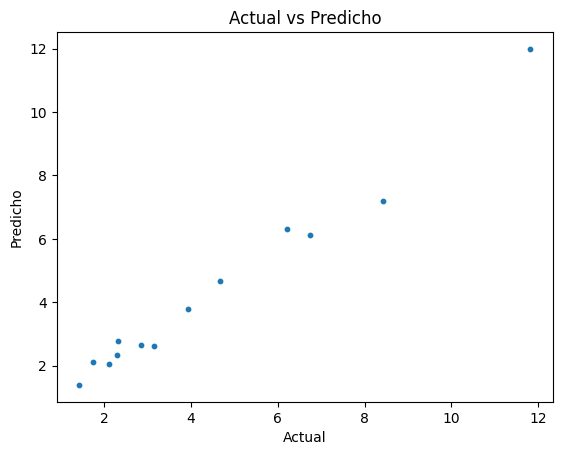

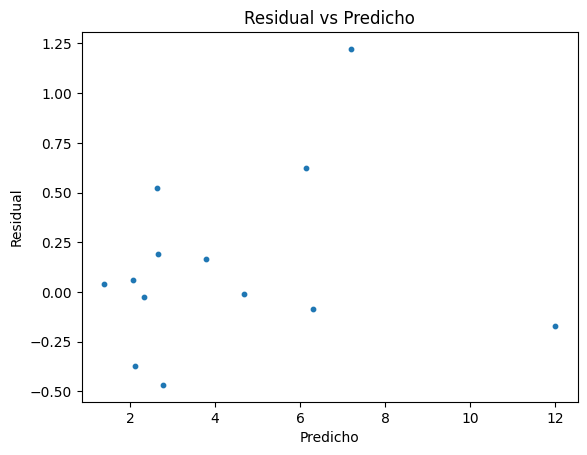

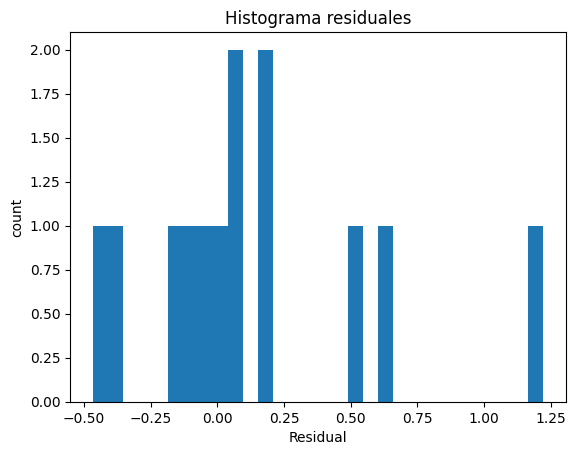

Typea
D    0.210245
I    0.618052
Name: abs_err, dtype: float64


In [22]:
best = poly_df.iloc[0].to_dict()
best_deg = int(best["degree"])
best_lam = float(best["lam"])
print("BEST:", best)

k=0
tr = get_fold(train_all, k)
va = get_fold(val_all, k)

med, mu, sig, cats = fit_preprocess_stats(tr)
Xtr, ytr = transform(tr, med, mu, sig, cats, add_bias=False)
Xva, yva = transform(va, med, mu, sig, cats, add_bias=False)

Xtr = poly_expand_num(Xtr, num_dim=len(FEATURES_NUM), degree=best_deg)
Xva = poly_expand_num(Xva, num_dim=len(FEATURES_NUM), degree=best_deg)

Xtr = add_bias(Xtr)
Xva = add_bias(Xva)

w = fit_ridge(Xtr, ytr, best_lam)
pred = Xva @ w
res  = yva - pred

# Solo para el primer fold (evaluacion)
plt.figure()
plt.scatter(yva, pred, s=10)
plt.title("Actual vs Predicho")
plt.xlabel("Actual")
plt.ylabel("Predicho")
plt.show()

plt.figure()
plt.scatter(pred, res, s=10)
plt.title("Residual vs Predicho")
plt.xlabel("Predicho")
plt.ylabel("Residual")
plt.show()

plt.figure()
plt.hist(res, bins=30)
plt.title("Histograma residuales")
plt.xlabel("Residual")
plt.ylabel("count")
plt.show()

# Error por tipo de material
# - I = Indirect band gap
# - D = Direct band gap
va_tmp = va.copy()
va_tmp["pred"] = pred
va_tmp["abs_err"] = np.abs(va_tmp[TARGET].values - pred)
print(va_tmp.groupby(COL_TYPE)["abs_err"].mean())

In [23]:
full_train = pd.concat([train_all, val_all], ignore_index=True)

med, mu, sig, cats = fit_preprocess_stats(full_train)
Xtr, ytr = transform(full_train, med, mu, sig, cats, add_bias=False)
Xte, yte = transform(test_all,  med, mu, sig, cats, add_bias=False)

Xtr = poly_expand_num(Xtr, num_dim=len(FEATURES_NUM), degree=best_deg)
Xte = poly_expand_num(Xte, num_dim=len(FEATURES_NUM), degree=best_deg)

Xtr = add_bias(Xtr)
Xte = add_bias(Xte)

w = fit_ridge(Xtr, ytr, best_lam)
pte = Xte @ w

print("TEST RMSE:", rmse(yte, pte))
print("TEST MAE :", mae(yte, pte))
print("TEST R2  :", r2(yte, pte))

TEST RMSE: 0.2910576829800377
TEST MAE : 0.22709831485842372
TEST R2  : 0.9926181569514578
